In [35]:
from pathlib import Path
from io import StringIO
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---------- CONFIG ----------

DATA_FILE = Path("data/anonymized_data.csv") 
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("results/regression")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [76]:

# --------------------------------------------
# Runs OLS with HC1 robust SEs for each tone, split by reviewer identity
# (Disclosed / Undisclosed / Full Data). Saves tidy coefficients + model metadata.
# --------------------------------------------


OUT_DIR   = Path("results/regression")

TONE_VARS = [
    'Weighted_Appreciative', 'Weighted_Constructive',
    'Weighted_Questioning', 'Weighted_Critical'
]

BASE_VARS = [
    'gender_male', 'race_white', 'region_west', 'top_100',
    'academic_age', 'avg_c2', 'work_count',
    'source_nature', 'pub_year_scaled',
    'days_received_to_accepted', 'total_authors', 'word_count'  
]

FIELD_VARS = [
    'field_Arts and Humanities', 
    'field_Agricultural and Biological Sciences',
    'field_Biochemistry, Genetics and Molecular Biology',
    'field_Business, Management and Accounting', 
    'field_Chemistry',
    'field_Computer Science', 
    'field_Decision Sciences', 
    'field_Dentistry',
    'field_Earth and Planetary Sciences', 
    'field_Economics, Econometrics and Finance',
    'field_Engineering', 
    'field_Environmental Science', 
    'field_Health Professions',
    'field_Immunology and Microbiology', 
    'field_Materials Science', 
    'field_Mathematics', 
    # 'field_Medicine' intentionally %%%%  excluded as reference
    'field_Neuroscience', 
    'field_Nursing', 
    'field_Pharmacology, Toxicology and Pharmaceutics', 
    'field_Physics and Astronomy', 
    'field_Psychology',
    'field_Social Sciences', 
    'field_Veterinary'
]

IDENTITY_SLICES = {
    'Disclosed':   lambda d: (d['disclosed_reviewer'] == 1),
    'Undisclosed': lambda d: (d['disclosed_reviewer'] == 0),
    'Full Data':   lambda d: pd.Series(True, index=d.index)  
}

def _prep_base_df(df: pd.DataFrame) -> pd.DataFrame:
    """Clean/engineer variables once."""
    df = df.copy()

    # split required columns into (a) modeling; (b) filtering/engineering
    required_model = set(TONE_VARS + BASE_VARS + FIELD_VARS)
    required_other = {
        'disclosed_reviewer',              #  for identity filters
        'publication_year'                 
    }
    missing = [c for c in (required_model | required_other) if c not in df.columns]
    
    if 'pub_year_scaled' in missing and 'publication_year' in df.columns:
        missing = [m for m in missing if m != 'pub_year_scaled']
    if missing:
        raise ValueError(f"Missing required columns in data: {missing}")

    if 'pub_year_scaled' not in df.columns:
        df['pub_year_scaled'] = df['publication_year'] - df['publication_year'].min() + 1

    base = df[
        (df['total_authors'] > 0) &
        (df['total_authors'] <= 20) &
        (df['academic_age'] <= 80) &
        (df['word_count'] >= 5)
    ].copy() # Filtered to remove unreasonably large outliers or very short reviews not caryying tone

    for c in TONE_VARS + BASE_VARS + [f for f in FIELD_VARS if f in base.columns]:
        base[c] = pd.to_numeric(base[c], errors='coerce')

    return base

def _available_field_vars(df: pd.DataFrame) -> list:
    present = [c for c in FIELD_VARS if c in df.columns]
    # (no 'field_Medicine' since it's the reference)
    if not present:
        print("WARNING: No FIELD_VARS found in data; proceeding without field controls.")
    return present

def _fit_one_model(df: pd.DataFrame, dep: str, indep: list):
    """Fit OLS with HC1 robust SEs and return tidy coefficients + model meta."""
    use_cols = indep + [dep]
    d = df[use_cols].dropna().copy()
    if d.empty or d.shape[0] < 5:
        return None, None

    # Cast booleans to ints to avoid collinearity oddities
    bool_cols = d.select_dtypes(include=['bool']).columns.tolist()
    if bool_cols:
        d[bool_cols] = d[bool_cols].astype(int)

    d = d.apply(pd.to_numeric, errors='coerce').dropna()
    if d.empty:
        return None, None

    y = d[dep]
    X = d[indep]
    X = sm.add_constant(X, has_constant='add')

    model = sm.OLS(y, X).fit(cov_type='HC1')  # HC1 robust SE

    params = model.params.rename('Coefficient')
    se     = model.bse.rename('SE')
    tvals  = model.tvalues.rename('t')
    pvals  = model.pvalues.rename('p')
    ci     = model.conf_int(alpha=0.05)
    ci.columns = ['CI_lower', 'CI_upper']

    coef = (
        pd.concat([params, se, tvals, pvals, ci], axis=1)
          .reset_index()
          .rename(columns={'index': 'Feature'})
    )

    meta = {
        "Adj_R_squared": float(np.round(model.rsquared_adj, 4)) if model.rsquared_adj is not None else np.nan,
        "F_statistic":   float(np.round(model.fvalue, 4)) if model.fvalue is not None else np.nan,
        "N_obs":         int(model.nobs),
        "MSE":           float(np.mean(model.resid**2)),
        "RMSE":          float(np.sqrt(np.mean(model.resid**2))),
    }
    return coef, meta

def run_all():
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(DATA_FILE)
    base = _prep_base_df(df)
    field_vars = _available_field_vars(base)

    tidy_all, meta_all = [], []

    for identity, filt in IDENTITY_SLICES.items():
        df_id = base[filt(base)]

        for dep in TONE_VARS:
         
            tone_controls = [t for t in TONE_VARS if t != dep]

            X_cols = BASE_VARS + field_vars + tone_controls

            # Include disclosed_reviewer as a predictor **only** in Full Data
            if identity == 'Full Data':
                if 'disclosed_reviewer' not in df_id.columns:
                    raise ValueError("Column 'disclosed_reviewer' not found but required for Full Data models.")
                X_cols = ['disclosed_reviewer'] + X_cols 

            X_cols = [c for c in X_cols if c in df_id.columns]

            coef_df, meta = _fit_one_model(df_id, dep, X_cols)
            model_key = f"{dep}__{identity.replace(' ', '').lower()}"

            if coef_df is None:
                print(f"SKIP: {model_key} (insufficient data)")
                continue

            # identity/tone for downstream plotting
            coef_df.insert(0, 'Tone', dep)
            coef_df.insert(1, 'Identity', identity)

            tidy_all.append(coef_df)

            meta_row = {'Model': model_key, 'Tone': dep, 'Identity': identity}
            meta_row.update(meta)
            meta_all.append(meta_row)

            # per-model export
            coef_df.to_csv(OUT_DIR / f"coeffs_{model_key}.csv", index=False)
            print(f"Completed: {model_key} (n={meta['N_obs']})")

    # combined tidy outputs
    tidy_all_df = pd.concat(tidy_all, ignore_index=True) if tidy_all else pd.DataFrame()
    meta_all_df = pd.DataFrame(meta_all)

    tidy_all_df.to_csv(OUT_DIR / "coefficients_tidy_all.csv", index=False)
    meta_all_df.to_csv(OUT_DIR / "model_meta_all.csv", index=False)

    print(f"\nSaved: {OUT_DIR/'coefficients_tidy_all.csv'}")
    print(f"Saved: {OUT_DIR/'model_meta_all.csv'}")

if __name__ == "__main__":
    run_all()
    print("Regression analysis completed.")


Completed: Weighted_Appreciative__disclosed (n=15993)
Completed: Weighted_Constructive__disclosed (n=15993)
Completed: Weighted_Questioning__disclosed (n=15993)
Completed: Weighted_Critical__disclosed (n=15993)
Completed: Weighted_Appreciative__undisclosed (n=60647)
Completed: Weighted_Constructive__undisclosed (n=60647)
Completed: Weighted_Questioning__undisclosed (n=60647)
Completed: Weighted_Critical__undisclosed (n=60647)
Completed: Weighted_Appreciative__fulldata (n=76640)
Completed: Weighted_Constructive__fulldata (n=76640)
Completed: Weighted_Questioning__fulldata (n=76640)
Completed: Weighted_Critical__fulldata (n=76640)

Saved: results\regression\coefficients_tidy_all.csv
Saved: results\regression\model_meta_all.csv
Regression analysis completed.


In [41]:

# ---------- paths ----------
IN_FILE  = Path("results/regression/coefficients_tidy_all.csv")
OUT_DIR  = Path("results/regression/tables")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- config ----------
TONE_ORDER      = ['Weighted_Appreciative','Weighted_Constructive','Weighted_Questioning','Weighted_Critical']
IDENTITY_ORDER  = ['Full Data','Undisclosed','Disclosed']


FEATURE_ORDER = [
    # main confounders first
    'gender_male','race_white','top_100','region_west',
    # other controls 
    'academic_age','work_count','avg_c2','source_nature','pub_year_scaled',
    'days_received_to_accepted','total_authors','word_count',
    # identity predictor (only has coeffs in Full Data)
    'disclosed_reviewer',
    # tone covariates (these have coeffs only in the *other* tone models)
    'Weighted_Appreciative','Weighted_Constructive','Weighted_Questioning','Weighted_Critical',
]

LABEL_MAP = {
    'gender_male': 'Gender: Male',
    'race_white': 'Race: White',
    'top_100': 'Affiliation rank: Top 100',
    'region_west': 'Region: Western group',
    
    'academic_age': 'Academic age',
    'work_count': 'Number of prior publications',
    'avg_c2': 'Average prior impact',
    'source_nature': 'Source: Nature Comm.',
    'pub_year_scaled': 'Publication year (scaled)',
    'days_received_to_accepted': 'Review duration (days)',
    'total_authors': 'Team size',
    'word_count': 'Review length (words)',
    'disclosed_reviewer': 'Reviewer identity disclosed',
    
    'Weighted_Appreciative': 'Tone covariate: Appreciative',
    'Weighted_Constructive': 'Tone covariate: Constructive',
    'Weighted_Questioning': 'Tone covariate: Questioning',
    'Weighted_Critical':    'Tone covariate: Critical',
    'const': 'Intercept'
}
TONE_LABEL = {
    'Weighted_Appreciative': 'Appreciative',
    'Weighted_Constructive': 'Constructive',
    'Weighted_Questioning':  'Questioning',
    'Weighted_Critical':     'Critical'
}

# ---------- load tidy results ----------
df_results = pd.read_csv(IN_FILE)

# coerce numerics
for c in ['Coefficient','SE','p','CI_lower','CI_upper','t']:
    if c in df_results.columns:
        df_results[c] = pd.to_numeric(df_results[c], errors='coerce')

# drop field_* rows from the table (models still controlled for them)
mask_field = df_results['Feature'].str.startswith('field_', na=False)
df_nofields = df_results.loc[~mask_field].copy()

# drop intercept
#df_nofields = df_nofields[df_nofields['Feature'] != 'const']

# keep only features we want to display (including tone covariates)
keep = [f for f in FEATURE_ORDER if f in df_nofields['Feature'].unique()]
df_keep = df_nofields[df_nofields['Feature'].isin(keep)].copy()

def p_to_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def fmt_coef_se(row):
    b, se, p = row['Coefficient'], row['SE'], row['p']
    if pd.isna(b) or pd.isna(se):
        return ''
    stars = p_to_stars(p)
    return f"{b:.3f}{stars}\n({se:.3f})"

df_keep['Tone']     = pd.Categorical(df_keep['Tone'], categories=TONE_ORDER, ordered=True)
df_keep['Identity'] = pd.Categorical(df_keep['Identity'], categories=IDENTITY_ORDER, ordered=True)
df_keep['FeatureLabel'] = df_keep['Feature'].map(LABEL_MAP).fillna(df_keep['Feature'])
df_keep['Formatted'] = df_keep.apply(fmt_coef_se, axis=1)

# pivot to wide: rows = Feature, cols = (Identity, Tone)
wide = (
    df_keep
    .pivot_table(index='Feature',
                 columns=['Identity','Tone'],
                 values='Formatted',
                 aggfunc='first')
)

# reindex rows to our chosen order, then map pretty labels
wide = wide.reindex(index=keep)
wide.index = [LABEL_MAP.get(f, f) for f in wide.index]

# order columns and relabel tone headers
wide = wide.reindex(columns=pd.MultiIndex.from_product([IDENTITY_ORDER, TONE_ORDER]))
wide.columns = pd.MultiIndex.from_tuples([(idn, TONE_LABEL.get(t, t)) for idn, t in wide.columns],
                                         names=['Identity','Tone'])

# save combined table
OUT_ALL = OUT_DIR / "regression_table_all_identities.csv"
wide.to_csv(OUT_ALL, encoding='utf-8')
print(f"Saved combined table → {OUT_ALL.resolve()}")

# per-identity tables
for idn in IDENTITY_ORDER:
    sub = wide[idn]
    OUT_ONE = OUT_DIR / f"regression_table_{idn.replace(' ','_')}.csv"
    sub.to_csv(OUT_ONE, encoding='utf-8')
    print(f"Saved per-identity table → {OUT_ONE.resolve()}")

#  save tidy (long) version 
TIDY_OUT = OUT_DIR / "regression_tidy_for_tables.csv"
df_keep[['FeatureLabel','Identity','Tone','Coefficient','SE','p','Formatted']].to_csv(TIDY_OUT, index=False)
print(f"Saved tidy long table → {TIDY_OUT.resolve()}")


Saved combined table → C:\Users\ms13502\peer_review_project\results\regression\tables\regression_table_all_identities.csv
Saved per-identity table → C:\Users\ms13502\peer_review_project\results\regression\tables\regression_table_Full_Data.csv
Saved per-identity table → C:\Users\ms13502\peer_review_project\results\regression\tables\regression_table_Undisclosed.csv
Saved per-identity table → C:\Users\ms13502\peer_review_project\results\regression\tables\regression_table_Disclosed.csv
Saved tidy long table → C:\Users\ms13502\peer_review_project\results\regression\tables\regression_tidy_for_tables.csv


Saved figure → C:\Users\ms13502\peer_review_project\figures\regression_main_confounders.svg


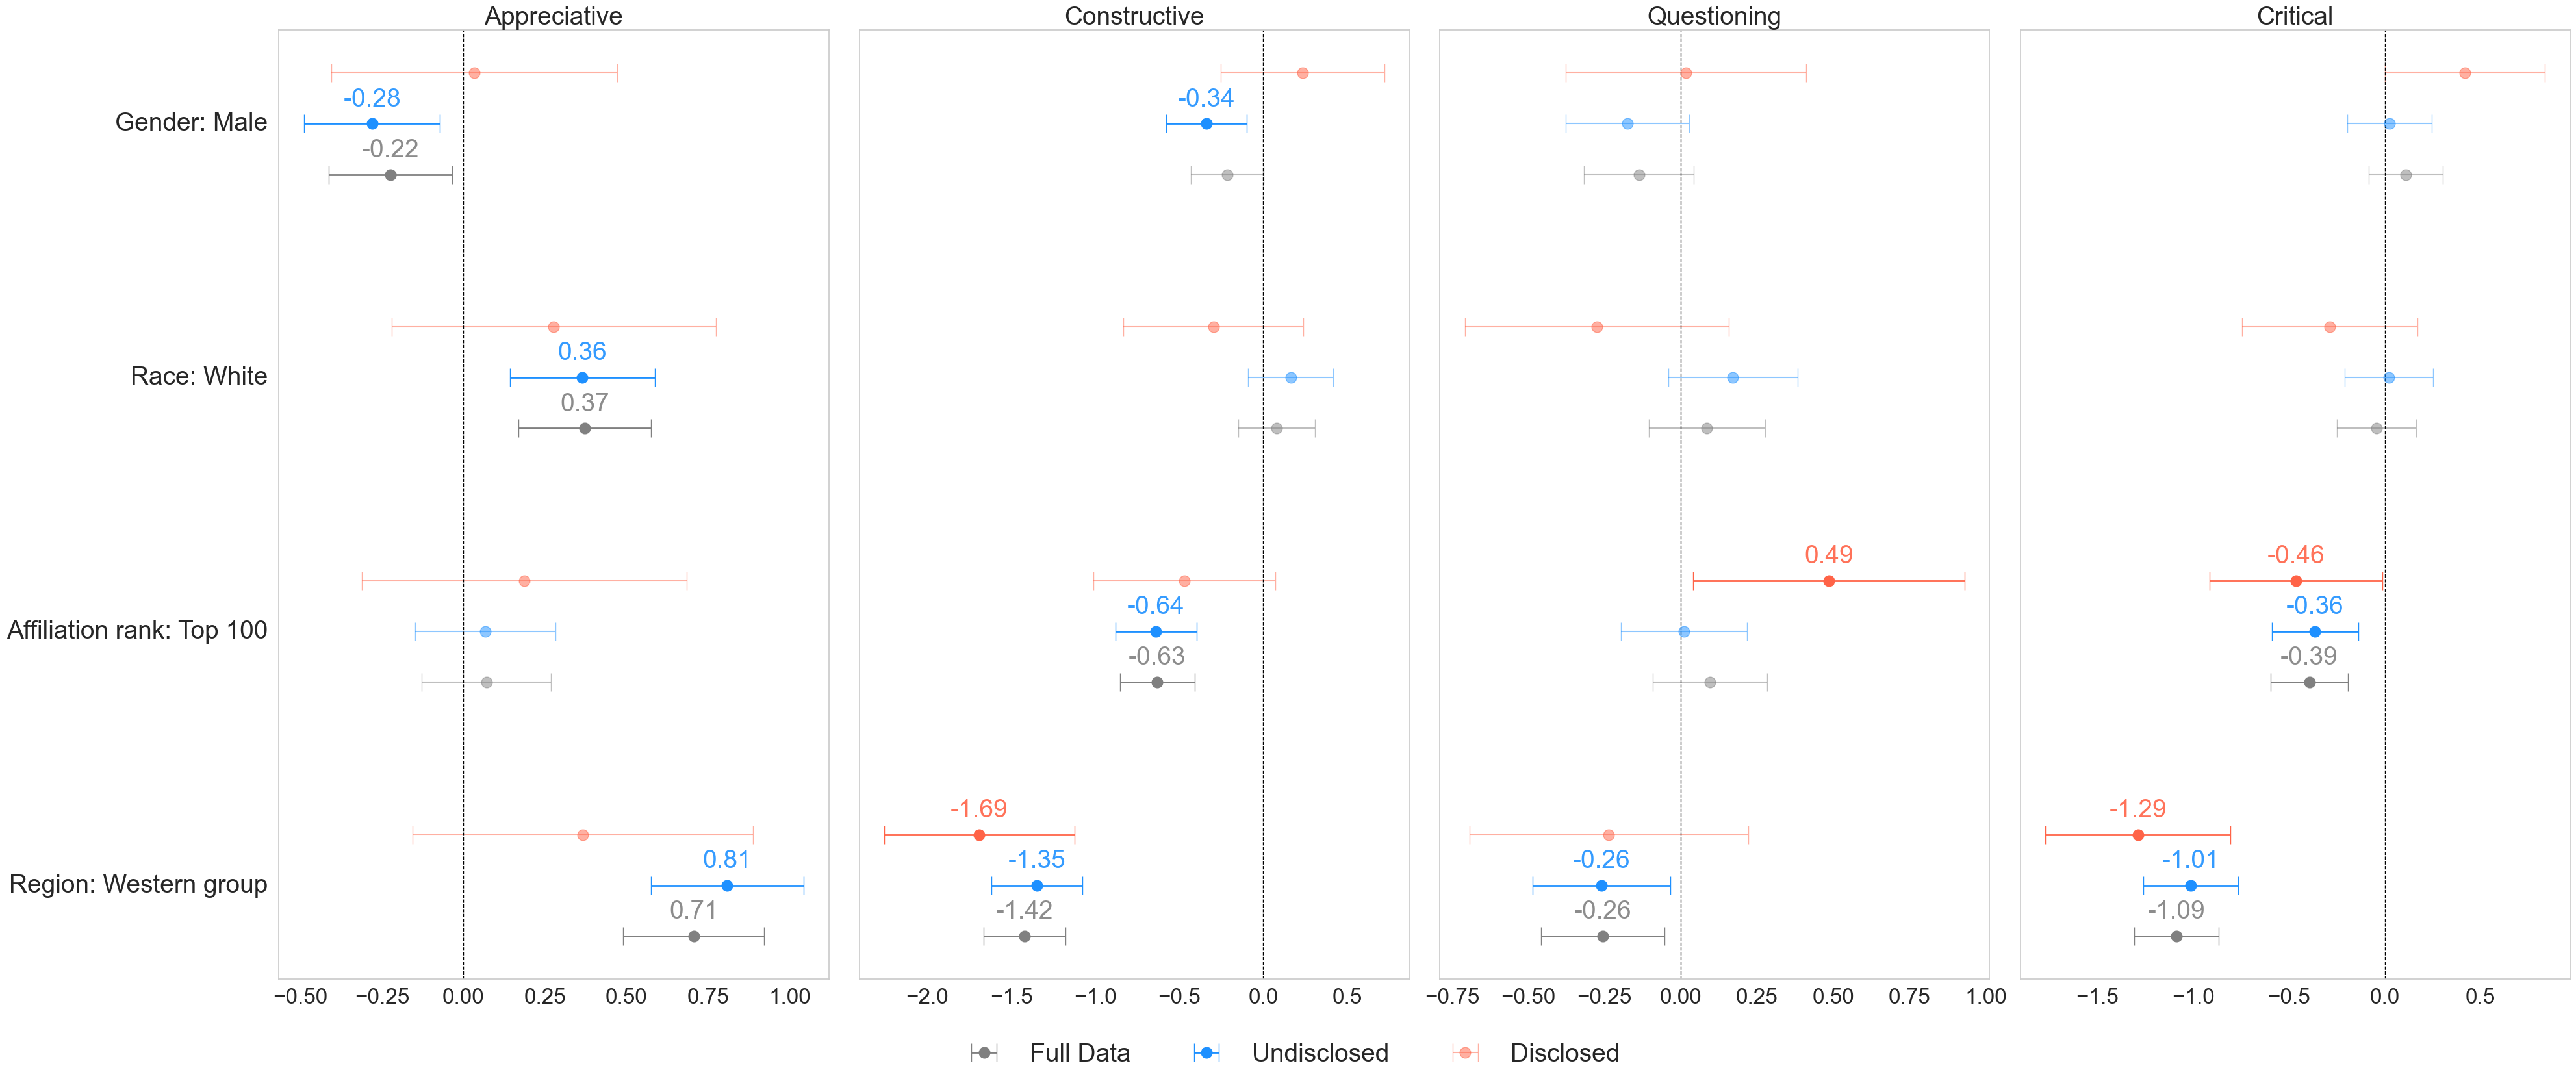

In [75]:
# Plots main confounders' coefficients with 95% CIs for
# Full Data / Undisclosed / Disclosed, faceted by tone.
# Reads:  results/regression/coefficients_tidy_all.csv
# Writes: figures/regression_main_confounders.svg
# -------------------
# Paths & I/O
# -------------------
IN_FILE = Path("results/regression/coefficients_tidy_all.csv")
OUT_PATH = Path("figures/regression_main_confounders.svg")
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_coeffs = pd.read_csv(IN_FILE)

# -------------------
# Config
# -------------------
TONE_ORDER = ['Weighted_Appreciative','Weighted_Constructive','Weighted_Questioning','Weighted_Critical']
TONE_LABEL = {
    'Weighted_Appreciative': 'Appreciative',
    'Weighted_Constructive': 'Constructive',
    'Weighted_Questioning':  'Questioning',
    'Weighted_Critical':     'Critical'
}

IDENTITY_ORDER = ['Full Data','Undisclosed','Disclosed']  # order

# Main confounders 
CUSTOM_FEATURE_ORDER = [

    'gender_male',
    'race_white',
    'top_100',
    'region_west',
]

LABEL_MAP = {
    'gender_male': 'Gender: Male',
    'race_white': 'Race: White',
    'top_100': 'Affiliation rank: Top 100',
    'region_west': 'Region: Western group'
}

# Style
sns.set(style="whitegrid", font_scale=1.6)
PALETTE = {'Full Data': 'gray', 'Undisclosed': 'dodgerblue', 'Disclosed': 'tomato'}

# -------------------
# Prep
# -------------------

for c in ['Coefficient','SE','p','CI_lower','CI_upper','t']:
    if c in df_coeffs.columns:
        df_coeffs[c] = pd.to_numeric(df_coeffs[c], errors='coerce')

# Filter out fields & intercept; keep only features we want to display
mask_field = df_coeffs['Feature'].str.startswith('field_', na=False)
dfp = df_coeffs.loc[~mask_field].copy()

# Keep requested features that exist in the data
features_present = [f for f in CUSTOM_FEATURE_ORDER if f in dfp['Feature'].unique()]

dfp = dfp[dfp['Feature'].isin(set(features_present))]

# Categorical sorters
dfp['Tone'] = pd.Categorical(dfp['Tone'], categories=TONE_ORDER, ordered=True)
dfp['Identity'] = pd.Categorical(dfp['Identity'], categories=IDENTITY_ORDER, ordered=True)

# -------------------
# Helper: significance and error bars
# -------------------
def is_sig(row):
    return (pd.notna(row['CI_lower']) and pd.notna(row['CI_upper'])
            and ((row['CI_lower'] > 0) or (row['CI_upper'] < 0)))

def err_left(row):
    return abs(row['Coefficient'] - row['CI_lower']) if pd.notna(row['CI_lower']) else np.nan

def err_right(row):
    return abs(row['CI_upper'] - row['Coefficient']) if pd.notna(row['CI_upper']) else np.nan

# -------------------
# Plot
# -------------------
tones = [t for t in TONE_ORDER if t in dfp['Tone'].unique()]
fig, axes = plt.subplots(1, len(tones), figsize=(10 * len(tones), 16), sharey=True)
if len(tones) == 1:
    axes = [axes]

for i, tone in enumerate(tones):
    ax = axes[i]
    tone_df = dfp[dfp['Tone'] == tone].copy()

    feature_order = [f for f in CUSTOM_FEATURE_ORDER if f in tone_df['Feature'].values][::-1]
    if 'disclosed_reviewer' in CUSTOM_FEATURE_ORDER and 'disclosed_reviewer' in tone_df['Feature'].values:
        feature_order = ['disclosed_reviewer'] + feature_order

    y_base = np.arange(len(feature_order))

    # --- plot the three reviewer identities ---
    for j, identity in enumerate(IDENTITY_ORDER):
        sub = tone_df[tone_df['Identity'] == identity]
        if sub.empty:
            continue
        offset = (j - 1) * 0.2

        for _, row in sub.iterrows():
            f = row['Feature']
            if f not in feature_order:
                continue
            y_idx = feature_order.index(f)
            y = y_base[y_idx] + offset

            sig   = is_sig(row)
            lw    = 2 if sig else 1.5
            alpha = 1.0 if sig else 0.5
            color = PALETTE.get(identity, 'gray')

            el = err_left(row); er = err_right(row)

            ax.errorbar(
                x = row['Coefficient'], y = y,
                xerr = [[el], [er]],
                fmt = 'o', color = color, linewidth = lw, alpha = alpha,
                capsize = 10, markersize = 12,
                label = identity if y_idx == 0 else ""
            )

            if sig:
                rgba = mcolors.to_rgba(color, alpha=0.9)
                # vertical offset so text doesn't overlap marker
                y_text = y + 0.05   
                x_text = row['Coefficient']

                ax.text(
                    x_text, y_text,
                    f"{row['Coefficient']:.2f}",
                    color=rgba,
                    fontsize=28,
                    ha='center',  
                    va='bottom'  
                )

    # ---  feature labels only for the left-most subplot ---
    if i == 0:
        x0, x1 = ax.get_xlim()
        dx = (x1 - x0)
        for idx, feature in enumerate(feature_order):
            label = LABEL_MAP.get(feature, feature)
           
            ax.text(x0 - 0.02 * dx, y_base[idx], label, va='center', ha='right', fontsize=28)

    # vertical reference line and cleanup
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1)

    # turn OFF ticks & tick labels everywhere (since we use manual text only on leftmost subplot)
    ax.tick_params(axis='x', labelsize=24)
    ax.set_yticks([])  
    ax.set_yticklabels([])
    ax.set_title(TONE_LABEL.get(tone, tone), fontsize=28)  
    ax.grid(False)

# legend + save 

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
   # title='Reviewer Identity',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.06),
    ncol=3,
    frameon=False, fontsize=28
)

plt.tight_layout()
plt.savefig(OUT_PATH, format='svg', dpi=300, bbox_inches='tight')
print(f"Saved figure → {OUT_PATH.resolve()}")
plt.show()
